
--- Analizando: 00039425-7f3a-42aa-ac13-834aaa2b6b92 ---
INFO JSON: Edad: 15, Género: male, Estado: healthy
Probabilidad de tos (CSV): 0.9609


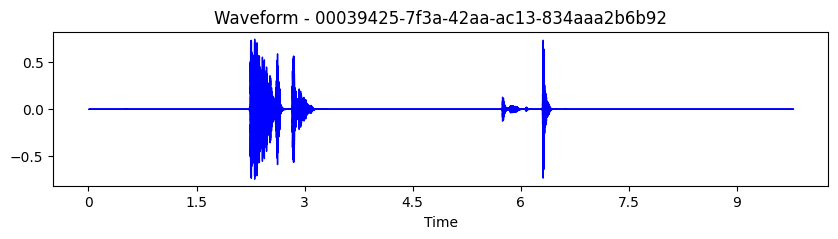


--- Analizando: 0009eb28-d8be-4dc1-92bb-907e53bc5c7a ---
INFO JSON: Edad: 34, Género: male, Estado: healthy
Probabilidad de tos (CSV): 0.9301


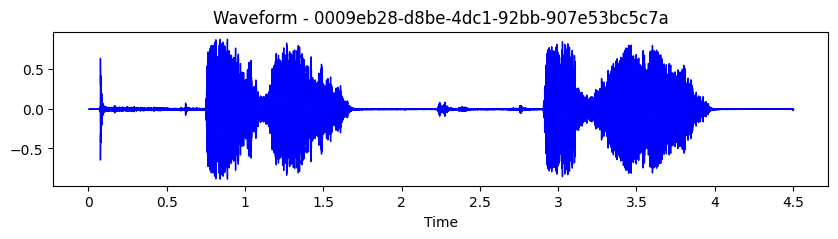


--- Analizando: 001328dc-ea5d-4847-9ccf-c5aa2a3f2d0f ---
INFO JSON: Edad: 21, Género: male, Estado: healthy
Probabilidad de tos (CSV): 0.9968


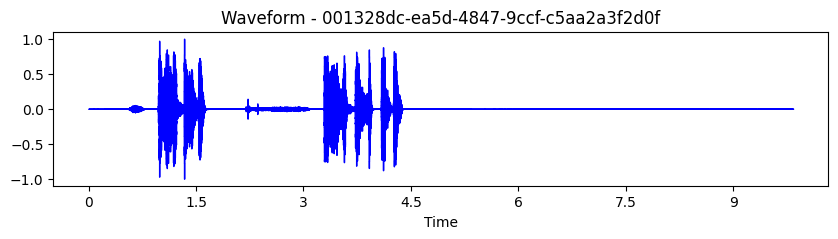

In [26]:
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import json
import os
from IPython.display import Audio, display
import seaborn as sns

# 1. Cargar el mapa (CSV)
csv_path = '../../DATA/metadata_compiled.csv'
df = pd.read_csv(csv_path)

# 2. Filtrar 3 ejemplos que tengan alta probabilidad de ser tos (>0.9)
# y que existan en la carpeta (por si acaso no tienes todos los archivos)
ejemplos = df[df['cough_detected'] > 0.9].head(3)

for index, row in ejemplos.iterrows():
    uuid = row['uuid']
    audio_file = f'../../DATA/{uuid}.wav'
    json_file = f'../../DATA/{uuid}.json'
    
    print(f"\n--- Analizando: {uuid} ---")
    
    # A. Cargar y mostrar Metadata del JSON
    if os.path.exists(json_file):
        with open(json_file, 'r') as f:
            data_json = json.load(f)
            print(f"INFO JSON: Edad: {data_json.get('age', 'N/A')}, Género: {data_json.get('gender', 'N/A')}, Estado: {data_json.get('status', 'N/A')}")
            print(f"Probabilidad de tos (CSV): {row['cough_detected']:.4f}")
    
    # B. Cargar Audio y Pintar Onda
    if os.path.exists(audio_file):
        y, sr = librosa.load(audio_file, sr=None)
        
        # Gráfico
        plt.figure(figsize=(10, 2))
        librosa.display.waveshow(y, sr=sr, color='blue')
        plt.title(f"Waveform - {uuid}")
        plt.show()
        
        # C. Botón para escuchar (Solo funciona en Jupyter/Colab)
        display(Audio(y, rate=sr))
    else:
        print(f"Archivo de audio {audio_file} no encontrado.")

=== EXPLORANDO LA CLASE NEGATIVA (NO TOS) ===

ID: 00014dcc-0f06-4c27-8c7b-737b18a2cf4c
Probabilidad de ser tos: 0.0155 (MUY BAJA)
SNR (Ruido): 7.33


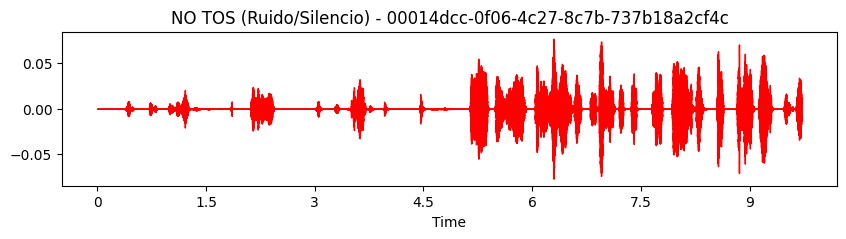


ID: 0012c608-33d0-4ef7-bde3-75a0b1a0024e
Probabilidad de ser tos: 0.0482 (MUY BAJA)
SNR (Ruido): 0.00


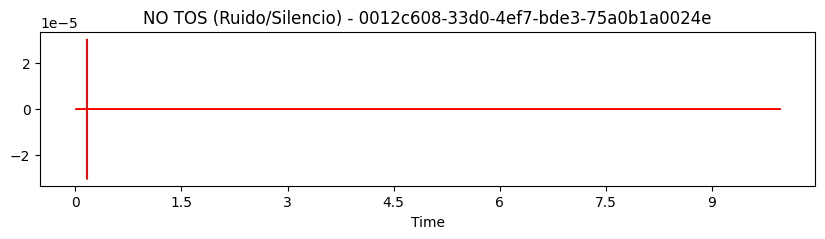


ID: 001c85a8-cc4d-4921-9297-848be52d4715
Probabilidad de ser tos: 0.0735 (MUY BAJA)
SNR (Ruido): 23.01


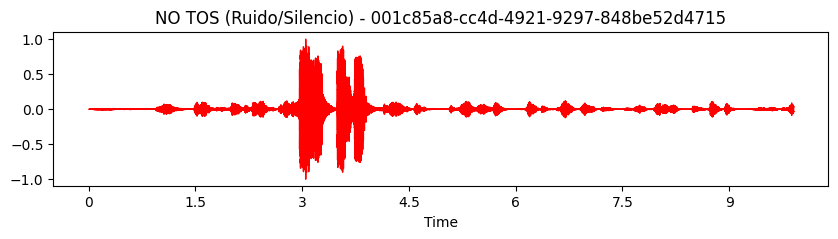

In [23]:
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os
from IPython.display import Audio, display

# 1. Configurar rutas
csv_path = '../../DATA/metadata_compiled.csv'
df = pd.read_csv(csv_path)

# 2. Filtrar 3 ejemplos de "NO TOS" (Probabilidad muy baja)
# Filtramos < 0.1 para estar muy seguros de que es ruido o silencio
ejemplos_no_tos = df[df['cough_detected'] < 0.1].head(3)

print("=== EXPLORANDO LA CLASE NEGATIVA (NO TOS) ===")

for index, row in ejemplos_no_tos.iterrows():
    uuid = row['uuid']
    audio_file = f'../../DATA/{uuid}.wav'
    
    print(f"\nID: {uuid}")
    print(f"Probabilidad de ser tos: {row['cough_detected']:.4f} (MUY BAJA)")
    print(f"SNR (Ruido): {row['SNR']:.2f}")
    
    if os.path.exists(audio_file):
        # Cargar audio
        y, sr = librosa.load(audio_file, sr=None)
        
        # Graficar para comparar visualmente con la tos
        plt.figure(figsize=(10, 2))
        librosa.display.waveshow(y, sr=sr, color='red') # En rojo para diferenciar
        plt.title(f"NO TOS (Ruido/Silencio) - {uuid}")
        plt.show()
        
        # Escuchar qué hay ahí (¿Habla? ¿Puertas? ¿Viento?)
        display(Audio(y, rate=sr))
    else:
        print(f"Archivo {uuid}.wav no encontrado en la carpeta DATA.")

FILTRADO DE DATOS

In [24]:
df = pd.read_csv('../../DATA/metadata_compiled.csv')

# Filtrar: Nos quedamos solo con las filas donde el primer médico (physician_1) puso una nota
# Esto nos da el subconjunto de "Expert Labels"
df_expert = df.dropna(subset=['quality_1'])

print(f"Total de audios en el dataset: {len(df)}")
print(f"Total de audios validados por expertos: {len(df_expert)}")

Total de audios en el dataset: 27550
Total de audios validados por expertos: 820


C:\Users\Usuario\AppData\Local\Temp\ipykernel_47268\1548513561.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_expert, x='gender', ax=axes[0, 0], palette='viridis')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_47268\1548513561.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_expert, x='status', ax=axes[0, 1], palette='magma')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_47268\1548513561.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_expert, x='quality_1', ax=axes[1, 0], palette='rocket')
C:\Users

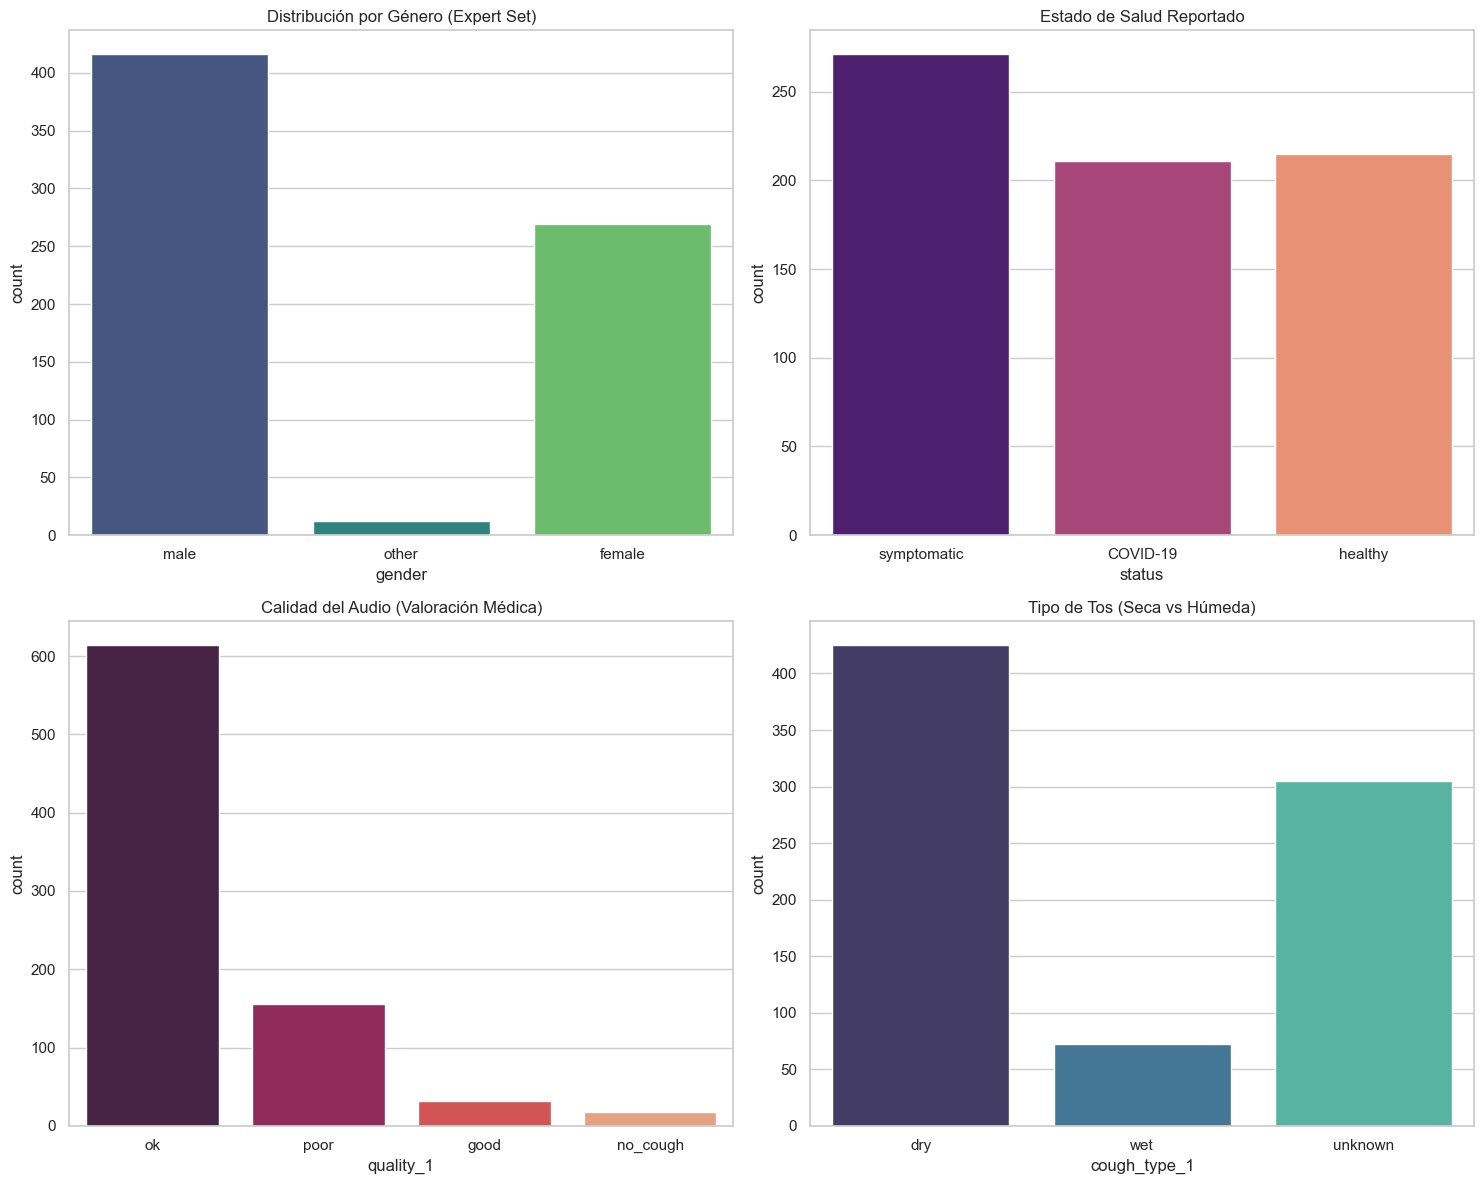

In [27]:
# Configurar el estilo visual
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Distribución por Género
sns.countplot(data=df_expert, x='gender', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Distribución por Género (Expert Set)')

# 2. Distribución por Estado de Salud (Reportado por el usuario)
sns.countplot(data=df_expert, x='status', ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Estado de Salud Reportado')

# 3. Calidad del audio según el Médico 1
sns.countplot(data=df_expert, x='quality_1', ax=axes[1, 0], palette='rocket')
axes[1, 0].set_title('Calidad del Audio (Valoración Médica)')

# 4. Tipo de tos (Seca vs Productiva) según Médico 1
sns.countplot(data=df_expert, x='cough_type_1', ax=axes[1, 1], palette='mako')
axes[1, 1].set_title('Tipo de Tos (Seca vs Húmeda)')

plt.tight_layout()
plt.show()

LIMPIEZA DE DATOS --> SOLO QUEDARNOS CON AQUELLOS ETIQUETADOS POR EXPERTOS

In [30]:
import pandas as pd
import os
from tqdm import tqdm

# 1. Cargar el mapa (CSV)
csv_path = '../../DATA/metadata_compiled.csv'
data_dir = '../../DATA/'
df = pd.read_csv(csv_path)

print(f"Total registros en el CSV original: {len(df)}")

# 2. El Filtro "Cualquier Experto"
# Buscamos filas donde al menos una de estas 4 columnas NO sea nula
columnas_expertos = ['quality_1', 'quality_2', 'quality_3', 'quality_4']
df_expert_any = df[df[columnas_expertos].notna().any(axis=1)].copy()

print(f"Registros etiquetados (por al menos 1 de los 4 médicos): {len(df_expert_any)}")

# 3. Consolidar Etiquetas (Opcional pero muy útil para tu TFM)
# Vamos a crear una columna 'quality_final' que recoja la opinión disponible
def consolidar_etiqueta(row):
    for col in columnas_expertos:
        if pd.notna(row[col]):
            return row[col]
    return None

df_expert_any['quality_consolidated'] = df_expert_any.apply(consolidar_etiqueta, axis=1)

# 4. Verificar existencia física del .wav
print("\nVerificando archivos en el disco...")
df_expert_any['archivo_existe'] = df_expert_any['uuid'].apply(
    lambda x: os.path.exists(os.path.join(data_dir, f"{x}.wav"))
)

df_expert_gold = df_expert_any[df_expert_any['archivo_existe'] == True].copy()
df_expert_gold.drop(columns=['archivo_existe'], inplace=True)

print(f"\n✅ Dataset limpio")
print(f"Total audios validados existentes: {len(df_expert_gold)}")

# Guardar
df_expert_gold.to_csv('../../DATA/metadata_expert_gold.csv', index=False)

Total registros en el CSV original: 27550
Registros etiquetados (por al menos 1 de los 4 médicos): 2890

Verificando archivos en el disco...

✅ Dataset limpio
Total audios validados existentes: 2890


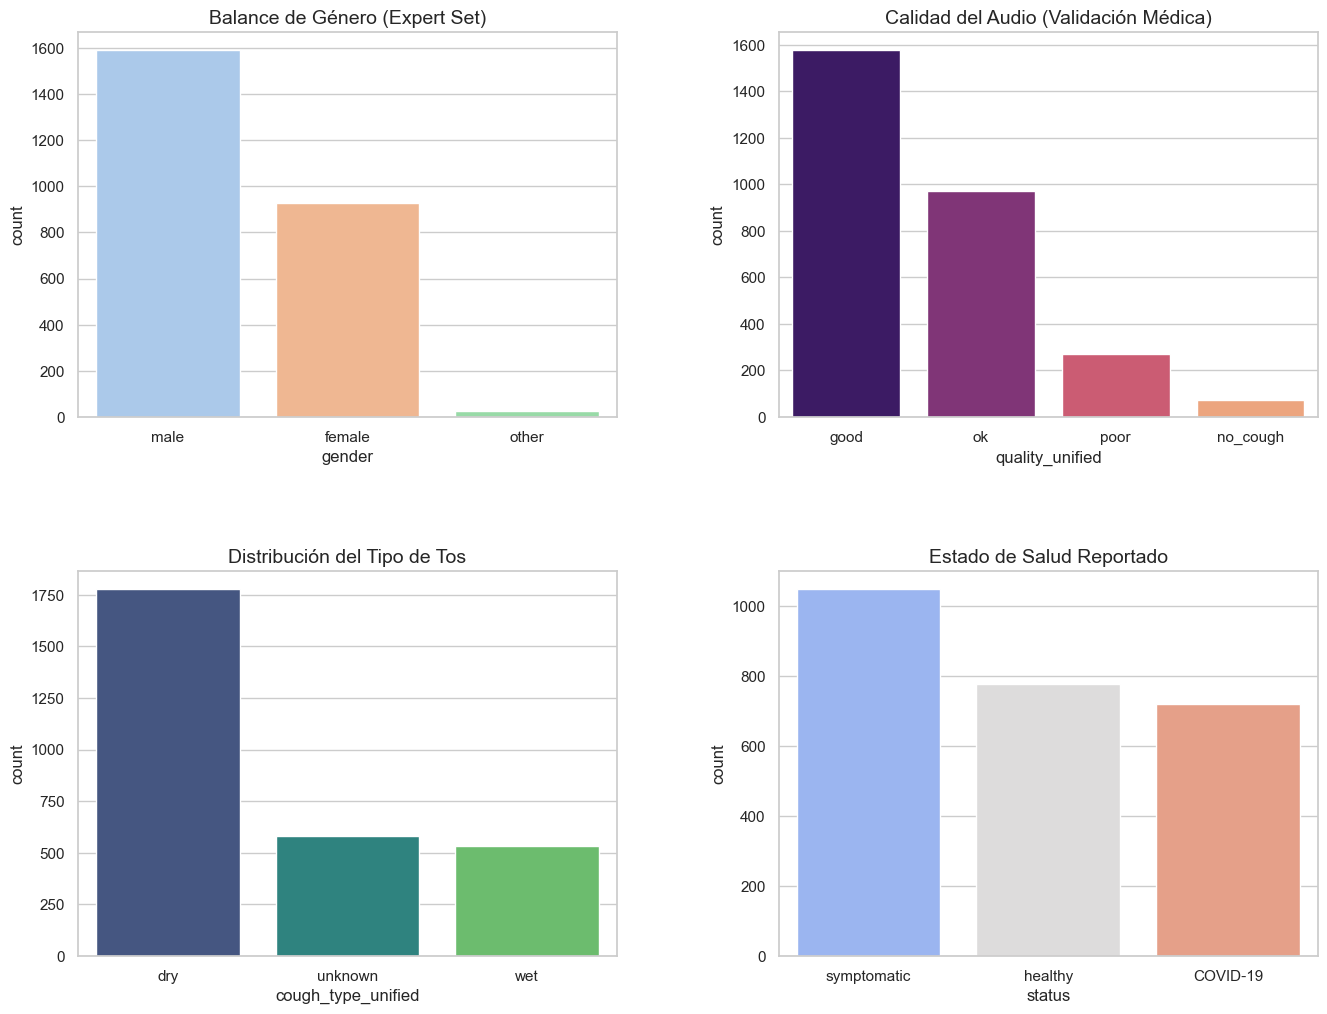

✅ ¡Columnas consolidadas! Ahora puedes usar 'cough_type_unified' para todo.


In [36]:

# 1. Cargar el dataset
# Asegúrate de que la ruta sea correcta (has usado ../../DATA/ en tu ejemplo)
df_gold = pd.read_csv('../../DATA/metadata_expert_gold.csv')

# 2. FUNCIONES DE CONSOLIDACIÓN (Para limpiar las columnas de los 4 médicos)
def consolidar_columna(row, prefijo):
    for i in range(1, 5):
        col = f'{prefijo}_{i}'
        if pd.notna(row.get(col)):
            return row[col]
    return 'unknown'

# Aplicamos la consolidación para Tipo de Tos y Calidad
df_gold['cough_type_unified'] = df_gold.apply(lambda r: consolidar_columna(r, 'cough_type'), axis=1)
df_gold['quality_unified'] = df_gold.apply(lambda r: consolidar_columna(r, 'quality'), axis=1)

# 3. CREAR EL LIENZO (2 filas y 2 columnas)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- GRÁFICA 1: Balance de Género ---
sns.countplot(data=df_gold, x='gender', hue='gender', ax=axes[0, 0], palette='pastel', legend=False)
axes[0, 0].set_title('Balance de Género (Expert Set)', fontsize=14)

# --- GRÁFICA 2: Calidad Percibida (Unificada) ---
sns.countplot(data=df_gold, x='quality_unified', hue='quality_unified', ax=axes[0, 1], palette='magma', legend=False)
axes[0, 1].set_title('Calidad del Audio (Validación Médica)', fontsize=14)

# --- GRÁFICA 3: Tipo de Tos (Unificada) ---
sns.countplot(data=df_gold, x='cough_type_unified', hue='cough_type_unified', ax=axes[1, 0], palette='viridis', legend=False)
axes[1, 0].set_title('Distribución del Tipo de Tos', fontsize=14)

# --- GRÁFICA 4: Estado de Salud ---
sns.countplot(data=df_gold, x='status', hue='status', ax=axes[1, 1], palette='coolwarm', legend=False)
axes[1, 1].set_title('Estado de Salud Reportado', fontsize=14)

# 4. MOSTRAR TODO EL PANEL
plt.show()

# Guardamos el cambio para que ya no tengas que pelearte con las 4 columnas
df_gold.to_csv('../../DATA/metadata_expert_gold.csv', index=False)
print("✅ ¡Columnas consolidadas! Ahora puedes usar 'cough_type_unified' para todo.")



In [37]:
df_toses = df_gold[df_gold['quality_unified'].isin(['good', 'ok'])].copy()
df_toses['label'] = 1

# 2. Filtramos los NO-TOSES (Clase 0)
# Primero los de los expertos
df_no_cough_expert = df_gold[df_gold['quality_unified'] == 'no_cough'].copy()

# Segundo: Buscamos refuerzos en el dataset general (fuera de los expertos)
# Cargamos el original para buscar audios con probabilidad bajísima
df_original = pd.read_csv('../../DATA/metadata_compiled.csv')
df_ruido_extra = df_original[df_original['cough_detected'] < 0.01].head(len(df_toses) - len(df_no_cough_expert))

# Unimos los ruidos
df_no_toses = pd.concat([df_no_cough_expert, df_ruido_extra])
df_no_toses['label'] = 0

# 3. CREAMOS EL DATASET FINAL EQUILIBRADO (50/50)
df_final_entrenamiento = pd.concat([df_toses, df_no_toses]).sample(frac=1).reset_index(drop=True)

print(f"Dataset equilibrado creado:")
print(f"- Toses (Clase 1): {len(df_toses)}")
print(f"- No Toses (Clase 0): {len(df_no_toses)}")

Dataset equilibrado creado:
- Toses (Clase 1): 2546
- No Toses (Clase 0): 820


In [42]:
import pandas as pd
import os

# 1. Definimos el objetivo (Cifra redonda como pediste)
OBJETIVO_POR_CLASE = 2500

# 2. Preparamos las TOSES (Clase 1)
# Cogemos las de expertos (Good/Ok) y limitamos a 2500
df_toses = df_gold[df_gold['quality_unified'].isin(['good', 'ok'])].copy()
df_toses['label'] = 1

# 3. Preparamos las NO-TOSES (Clase 0)
# Primero: Las que los expertos dijeron que NO son tos
df_no_cough_expert = df_gold[df_gold['quality_unified'] == 'no_cough'].copy()

# Segundo: ¿Cuántas nos faltan para llegar a 2500?
faltantes = OBJETIVO_POR_CLASE - len(df_no_cough_expert)

# Tercero: Buscamos en el resto del dataset original
df_original = pd.read_csv('../../DATA/metadata_compiled.csv')
expert_uuids = df_gold['uuid'].tolist()
df_resto = df_original[~df_original['uuid'].isin(expert_uuids)]

# Ordenamos por probabilidad de menor a mayor y cogemos las que faltan
df_ruido_extra = df_resto.sort_values(by='cough_detected').head(faltantes).copy()

# 4. UNIMOS TODO EN EL "POOL" TOTAL
df_no_toses_final = pd.concat([df_no_cough_expert, df_ruido_extra])
df_no_toses_final['label'] = 0

# Creamos el dataset final mezclado
df_final_pool = pd.concat([df_toses, df_no_toses_final]).sample(frac=1, random_state=42).reset_index(drop=True)

# 5. GUARDAR A CSV FINAL
ruta_csv_final = '../../DATA/metadata_final_tfm.csv'
df_final_pool.to_csv(ruta_csv_final, index=False)

# 5. VERIFICACIÓN FINAL
print(f"--- Dataset de Trabajo Creado ---")
print(f"Toses (Clase 1): {len(df_final_pool[df_final_pool['label'] == 1])}")
print(f"No Toses (Clase 0): {len(df_final_pool[df_final_pool['label'] == 0])}")
print(f"Total audios a procesar: {len(df_final_pool)}")


--- Dataset de Trabajo Creado ---
Toses (Clase 1): 2546
No Toses (Clase 0): 2500
Total audios a procesar: 5046


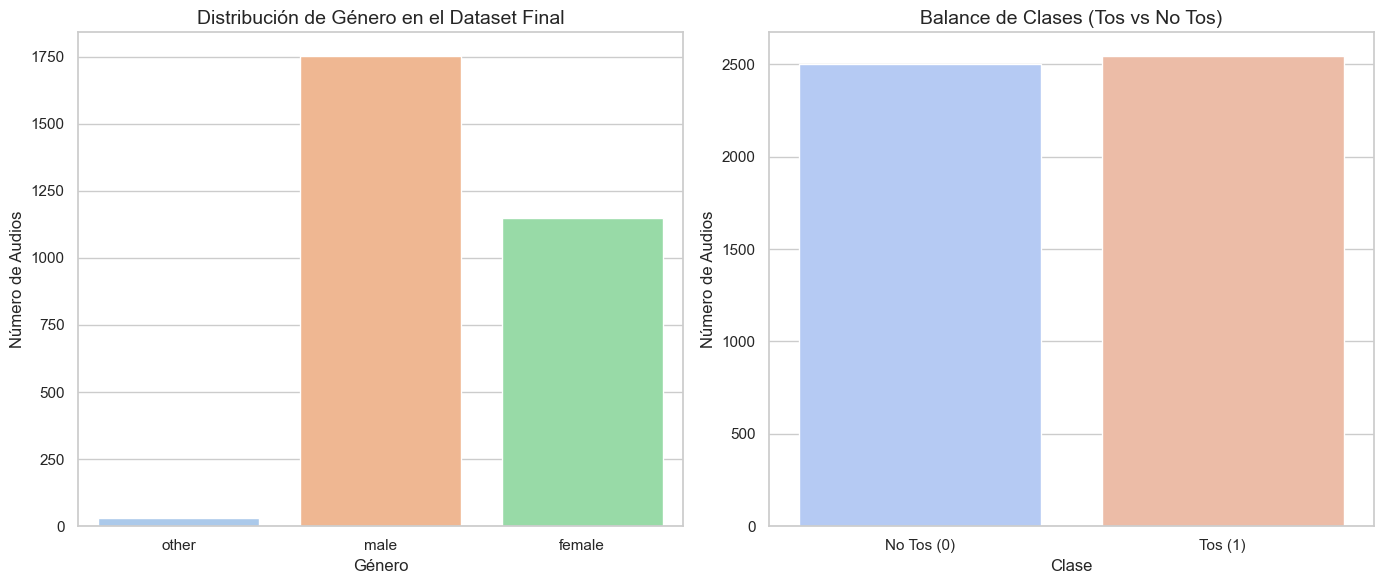

Resumen de género:
gender
NaN       2116
male      1753
female    1147
other       30
Name: count, dtype: int64


In [43]:


# Configuramos el estilo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- GRÁFICA 1: Balance de Género (Gender) ---
# Nota: Algunos de los audios nuevos de 'No Tos' podrían tener género 'unknown'
sns.countplot(data=df_final_pool, x='gender', hue='gender', ax=axes[0], palette='pastel', legend=False)
axes[0].set_title('Distribución de Género en el Dataset Final', fontsize=14)
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Número de Audios')

# --- GRÁFICA 2: Balance de Clases (Labels) ---
# Aquí veremos el 50/50 que hemos forzado
sns.countplot(data=df_final_pool, x='label', hue='label', ax=axes[1], palette='coolwarm', legend=False)
axes[1].set_title('Balance de Clases (Tos vs No Tos)', fontsize=14)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Tos (0)', 'Tos (1)'])
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Número de Audios')

plt.tight_layout()
plt.show()

# Extra: Ver los números exactos por género
print("Resumen de género:")
print(df_final_pool['gender'].value_counts(dropna=False))